# **Part 1: Visualization & Exploratory Data Analysis (EDA)**

### **Dataset Introduction**

In this project, we will work with the Palmer Penguins dataset, which contains measurements of penguins observed on islands near Antarctica.

Please download the dataset [penguins.csv](https://drive.google.com/file/d/1dv8A8v_sdf29p1At40S7KBslJPmBA3e9/view?usp=sharing) or from canvas.

### **Dataset Description**

Each row represents a penguin, and columns include:

- species – Penguin species
- island – Island where the penguin was found
- bill_length_mm – Bill length (mm)
- bill_depth_mm – Bill depth (mm)
- flipper_length_mm – Flipper length (mm)
- body_mass_g – Body mass (grams)
- sex – Sex of the penguin

Some values are missing, which makes this dataset ideal for practicing missing data handling.



Your task is to perform a comprehensive Exploratory Data Analysis (EDA) and visualization on the Palmer Penguins dataset. This project aims to deepen your understanding of data characteristics, relationships between variables, and effective data presentation using Python's data science libraries.

**Instructions:**

1.  **Load the Dataset:** Begin by loading the `penguins.csv` dataset into a pandas DataFrame.
2.  **Initial Data Inspection:** Perform an initial inspection to understand the dataset's structure. Display the first few rows, check data types and non-null values, and generate descriptive statistics.
3.  **Handle Missing Values:** Identify and address any missing values in the dataset. Clearly explain your chosen strategy for handling missing data (e.g., imputation, dropping rows/columns) and justify your decision.
4.  **Perform EDA and Visualization:** Conduct a thorough EDA, exploring distributions, relationships, and patterns within the data. You are required to use **at least three distinct types of visualizations** (e.g., histograms, scatter plots, box plots, bar charts). For each visualization:
    *   Justify your choice of plot type, explaining why it is suitable for the variables being analyzed.
    *   Clearly articulate what insights each visualization reveals about the data (e.g., distributions, correlations, outliers, group differences).
5.  **Summarize Key Findings:** Based on your EDA and visualizations, summarize the most important insights and observations about the Palmer Penguins dataset. Highlight any discovered patterns, trends, anomalies, or interesting relationships.
6.  **Final Task:** Present your complete EDA and visualization analysis, emphasizing key takeaways and interpretations of the observed data characteristics and relationships in a clear and concise manner.

---
## 1. Load the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("penguins.csv")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [2]:
SPECIES_ORDER = ["Adelie", "Chinstrap", "Gentoo"]
SEX_ORDER = ["Female", "Male"]

NUMERIC_COLS = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
LABELS = {
    "bill_length_mm": "Bill length (mm)",
    "bill_depth_mm": "Bill depth (mm)",
    "flipper_length_mm": "Flipper length (mm)",
    "body_mass_g": "Body mass (g)",
}

## 2. Initial Data Inspection

### 2.1 First few rows

In [3]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


### 2.2 Data types and non-null counts

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


### 2.3 Descriptive statistics (numeric columns)

In [5]:
df.describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.22,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00


### 2.4 Categorical columns

In [6]:
for col in ["species", "island", "sex"]:
    print(df[col].value_counts(dropna=False).to_string(), "\n")

species
Adelie       152
Gentoo       124
Chinstrap     68 

island
Biscoe       168
Dream        124
Torgersen     52 

sex
MALE      168
FEMALE    165
NaN        10
.           1 



## 3. Handle Missing Values

### 3.1 Where are the missing values?

In [7]:
df["sex"] = df["sex"].replace(".", np.nan)

missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "percent": (df.isna().mean() * 100).round(2),
})
missing

,missing,percent
species,0,0.00
island,0,0.00
bill_length_mm,2,0.58
bill_depth_mm,2,0.58
flipper_length_mm,2,0.58
body_mass_g,2,0.58
sex,11,3.20


In [8]:
df[df.isna().any(axis=1)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


In [9]:
all_measurements_missing = df[NUMERIC_COLS].isna().all(axis=1)
only_sex_missing = df["sex"].isna() & ~all_measurements_missing

print("Rows missing ALL four measurements (and sex):", all_measurements_missing.sum())
print("Rows missing ONLY sex:                        ", only_sex_missing.sum())
print("\nSpecies of the rows missing only sex:")
print(df.loc[only_sex_missing, "species"].value_counts().to_string())

Rows missing ALL four measurements (and sex): 2
Rows missing ONLY sex:                         9

Species of the rows missing only sex:
species
Adelie    5
Gentoo    4


### 3.2 Strategy and justification

There are two distinct missing-data patterns:

1. 2 rows are missing every measurement and sex. These rows are going to be dropped.
2. 9 rows are missing only `sex`. I considered the options predicting sex from the other measurements is possible, but it adds a model's assumptions into what should be a description of the raw data.

Decision: drop all rows with any missing value.

In [10]:
penguins = df.dropna().copy()
penguins["sex"] = penguins["sex"].str.strip().str.title()

removed = len(df) - len(penguins)
print(f"Rows before: {len(df)} | after: {len(penguins)} | removed: {removed} ({removed / len(df):.1%})")
print("Missing values remaining:", int(penguins.isna().sum().sum()))

pd.DataFrame({
    "before (%)": (df["species"].value_counts(normalize=True) * 100).round(1),
    "after (%)": (penguins["species"].value_counts(normalize=True) * 100).round(1),
})

Rows before: 344 | after: 333 | removed: 11 (3.2%)
Missing values remaining: 0


,before (%),after (%)
species,,
Adelie,44.2,43.8
Gentoo,36.0,35.7
Chinstrap,19.8,20.4


## 4. Exploratory Data Analysis and Visualization


### 4.1 Histograms: distribution of each measurement

Each measurement is a single variable, and a histogram is the standard way to see the shape of both where the values cluster and how spread out they are.

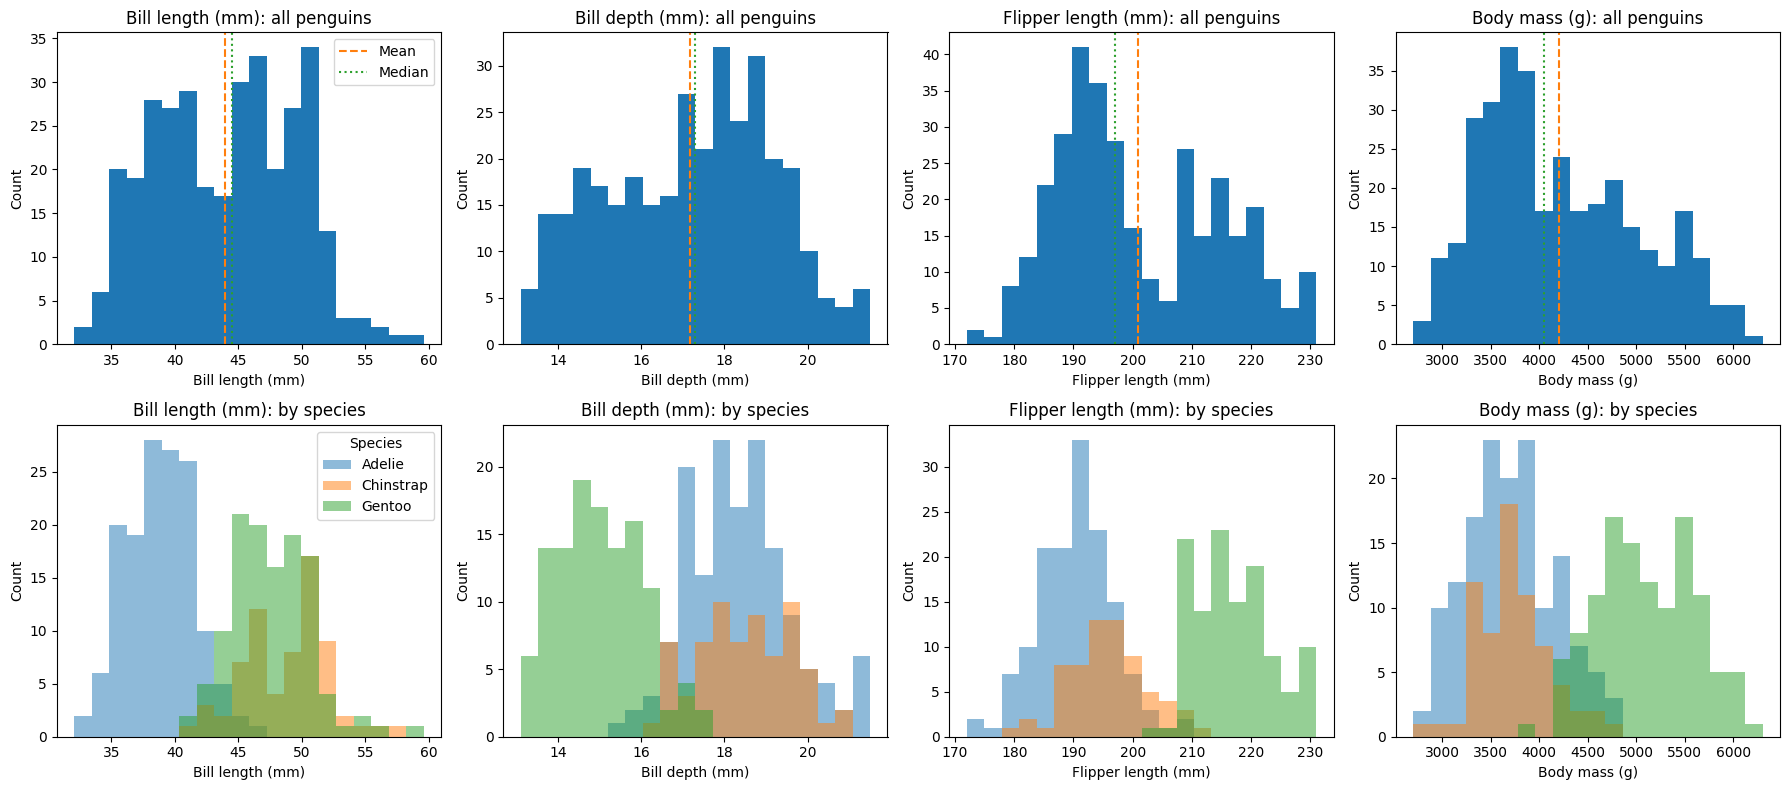

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(NUMERIC_COLS):
    bins = np.histogram_bin_edges(penguins[col], bins=20)

    axes[0, i].hist(penguins[col], bins=bins)
    axes[0, i].axvline(penguins[col].mean(), color="C1", linestyle="--", label="Mean")
    axes[0, i].axvline(penguins[col].median(), color="C2", linestyle=":", label="Median")
    axes[0, i].set_title(f"{LABELS[col]}: all penguins")
    axes[0, i].set_xlabel(LABELS[col])
    axes[0, i].set_ylabel("Count")

    for sp in SPECIES_ORDER:
        axes[1, i].hist(penguins.loc[penguins["species"] == sp, col], bins=bins,
                        alpha=0.5, label=sp)
    axes[1, i].set_title(f"{LABELS[col]}: by species")
    axes[1, i].set_xlabel(LABELS[col])
    axes[1, i].set_ylabel("Count")

axes[0, 0].legend()
axes[1, 0].legend(title="Species")

plt.tight_layout()
plt.show()


**Insights**

- Flipper length had two peaks: one peak around 190 mm and a second around 215 mm.
- Body mass is skewed to the right.

### 4.2 Bar chart: species counts on each island

Species and island are both categorical, and the quantity of interest is a count. Grouping the bars by island lets us compare species within each island side by side.

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,119
Dream,55,68,0
Torgersen,47,0,0


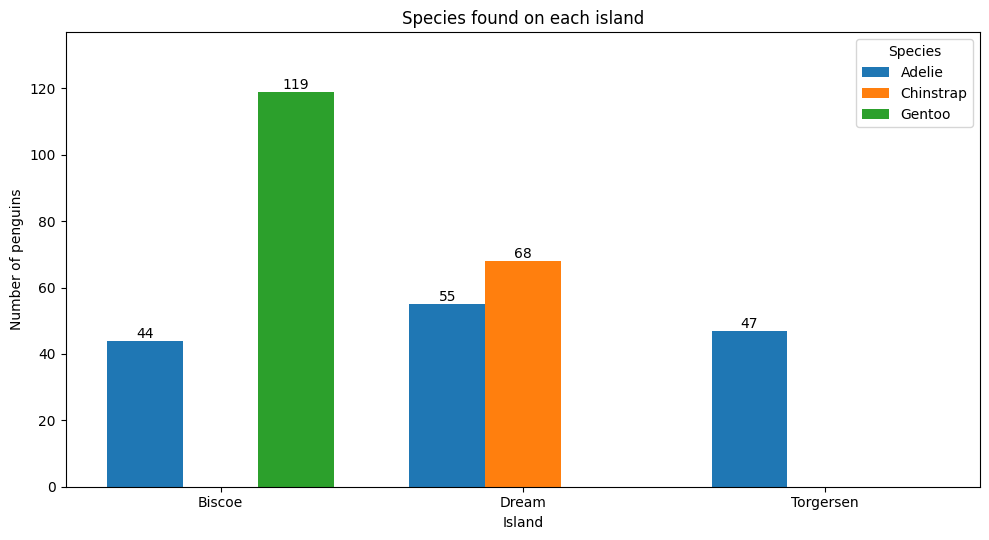

In [14]:
counts = pd.crosstab(penguins["island"], penguins["species"])[SPECIES_ORDER]
display(counts)

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(counts.index))
width = 0.25

for j, sp in enumerate(SPECIES_ORDER):
    bars = ax.bar(x + (j - 1) * width, counts[sp], width, label=sp)
    ax.bar_label(bars, labels=[str(v) if v > 0 else "" for v in counts[sp]])

ax.set_xticks(x, counts.index)
ax.set_xlabel("Island")
ax.set_ylabel("Number of penguins")
ax.set_title("Species found on each island")
ax.set_ylim(0, counts.values.max() * 1.15)
ax.legend(title="Species")
plt.tight_layout()
plt.show()

**Insights**

- Gentoo were found only on Biscoe
- Chinstrap only on Dream.
- Adelie is the only species found on all three islands

### 4.3 Box plots: body size by species and sex

**Why a box plot?** A box plot summarizes each group's median, middle 50%, typical range and individual outliers.


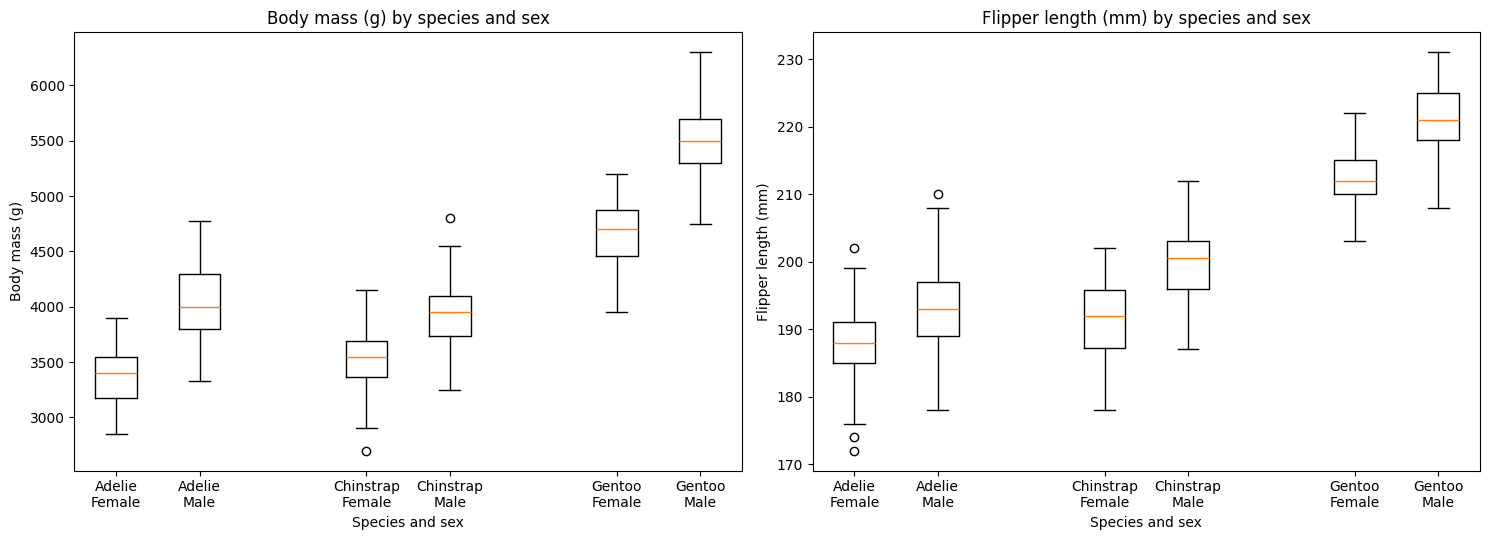

body_mass_g         flipper_length_mm       
                      median    mean            median   mean
species   sex                                                
Adelie    Female      3400.0  3368.8             188.0  187.8
          Male        4000.0  4043.5             193.0  192.4
Chinstrap Female      3550.0  3527.2             192.0  191.7
          Male        3950.0  3939.0             200.5  199.9
Gentoo    Female      4700.0  4679.7             212.0  212.7
          Male        5500.0  5484.8             221.0  221.5

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

groups = [(sp, sex) for sp in SPECIES_ORDER for sex in SEX_ORDER]
positions = [1, 2, 4, 5, 7, 8]  # a gap between each species
tick_labels = [f"{sp}\n{sex}" for sp, sex in groups]

for ax, col in zip(axes, ["body_mass_g", "flipper_length_mm"]):
    data = [penguins.loc[(penguins["species"] == sp) & (penguins["sex"] == sex), col]
            for sp, sex in groups]
    ax.boxplot(data, positions=positions)
    ax.set_xticks(positions, tick_labels)
    ax.set_title(f"{LABELS[col]} by species and sex")
    ax.set_xlabel("Species and sex")
    ax.set_ylabel(LABELS[col])

plt.tight_layout()
plt.show()

summary = (penguins.groupby(["species", "sex"])[["body_mass_g", "flipper_length_mm"]]
           .agg(["median", "mean"]).round(1))
summary

In [16]:
mass = penguins.groupby(["species", "sex"])["body_mass_g"].mean().unstack()
mass["male minus female (g)"] = (mass["Male"] - mass["Female"]).round(0)
mass["male heavier by (%)"] = ((mass["Male"] / mass["Female"] - 1) * 100).round(1)
mass.round(0)

sex,Female,Male,male minus female (g),male heavier by (%)
species,,,,
Adelie,3369.0,4043.0,675.0,20.0
Chinstrap,3527.0,3939.0,412.0,12.0
Gentoo,4680.0,5485.0,805.0,17.0


**Insights**

- Gentoo are by far the largest penguins.
- Adelie and Chinstrap are almost the same size.
- Males are larger than females in every species

## 5. Summary of Key Findings

1. Majority of the variation came form the different species types.
2. Gentoo are distinct in size while Adelie and Chinstrap are distinct in bill shape.
3. All species had sexual dimorphism.
4. Island and species are interconected: Gentoo live only on Biscoe, Chinstrap only on Dream, and Torgersen has only Adelie.


## 6. Final Presentation: Key Takeaways

Based on my EDA, the Palmer Penguins dataset is clean and well structured. Its main story is about three species with distinct body plans:

- Gentoo: found only on Biscoe.
- Chinstrap: found only on Dream.
- Adelie: the only species on all three islands.

The histograms showed that unusual overall distributions. The bar chart showed how the islands were connected to the species. The box plots quantified the size gap between Gentoo and the other two species.

The most important lesson from this EDA is that species must be accounted for in any further analysis.